**Introduction**


In this analysis  Support Vector Machines (SVM) are used to train a model to classify if an image contains a ship or not. The  feature representation method Histogram of Oriented Gradients (HOG) are used as the feature representation. Although deep learning approaches have proven there superiority in similar image recognition/classification problem, given the small size of the data set it is interesting to find out how a traditional computer vision approach performs in a situation like this.

In [1]:
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import json
from matplotlib import pyplot as plt
from skimage import color
from skimage.feature import hog
from sklearn import svm
from sklearn.metrics import classification_report,accuracy_score

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory
import os

folder = r"C:/Users/anasy/Downloads/shipsnet"

for f in os.listdir(folder):
    print(f)

# Any results you write to the current directory are saved as output.

sfbay_1.png
shipsnet.7z
shipsnet.json


In [14]:
f = open(r"C:\Users\anasy\Downloads\shipsnet\shipsnet.json")
dataset = json.load(f)
f.close()

dataset.keys()


dict_keys(['data', 'labels', 'locations', 'scene_ids'])

Load the data and see check how an image looks like

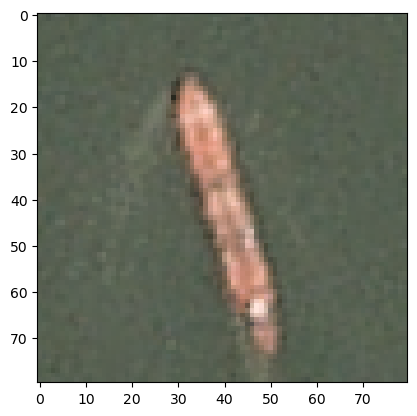

In [3]:
data = np.array(dataset['data']).astype('uint8')
img_length = 80
data = data.reshape(-1,3,img_length,img_length).transpose([0,2,3,1])

plt.imshow(data[51])

Convert the images to grayscale colorspace before calculating the HOG features for each image

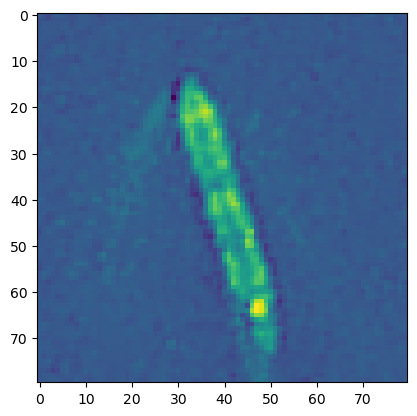

In [4]:
data_gray = [ color.rgb2gray(i) for i in data]
plt.imshow(data_gray[51])

In [5]:
ppc = 16
hog_images = []
hog_features = []
for image in data_gray:
    fd,hog_image = hog(image, orientations=8, pixels_per_cell=(ppc,ppc),cells_per_block=(4, 4),block_norm= 'L2',visualize=True)
    hog_images.append(hog_image)
    hog_features.append(fd)

The hog function of skimage returns a matrix that can be used to visualize the gradients

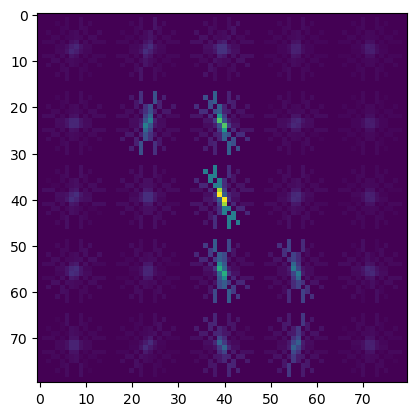

In [6]:
plt.imshow(hog_images[51])

In [7]:
labels =  np.array(dataset['labels']).reshape(len(dataset['labels']),1)

Fit a simple SVM classifier to the data . Make sure to shuffle the data before fitting it to the model

In [25]:
clf = svm.SVC()
hog_features = np.array(hog_features)
data_frame = np.hstack((hog_features,labels))
np.random.shuffle(data_frame)

In [27]:
#What percentage of data you want to keep for training
percentage = 80
partition = int(len(hog_features)*percentage/100)

In [29]:
x_train, x_test = data_frame[:partition,:-1],  data_frame[partition:,:-1]
y_train, y_test = data_frame[:partition,-1:].ravel() , data_frame[partition:,-1:].ravel()

clf.fit(x_train,y_train)
print(clf.get_params())


{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [31]:
y_pred = clf.predict(x_test)

In [12]:
print("Accuracy: "+str(accuracy_score(y_test, y_pred)))
print('\n')
print(classification_report(y_test, y_pred))

Accuracy: 0.9875


              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       431
         1.0       0.99      0.95      0.97       129

    accuracy                           0.99       560
   macro avg       0.99      0.98      0.98       560
weighted avg       0.99      0.99      0.99       560



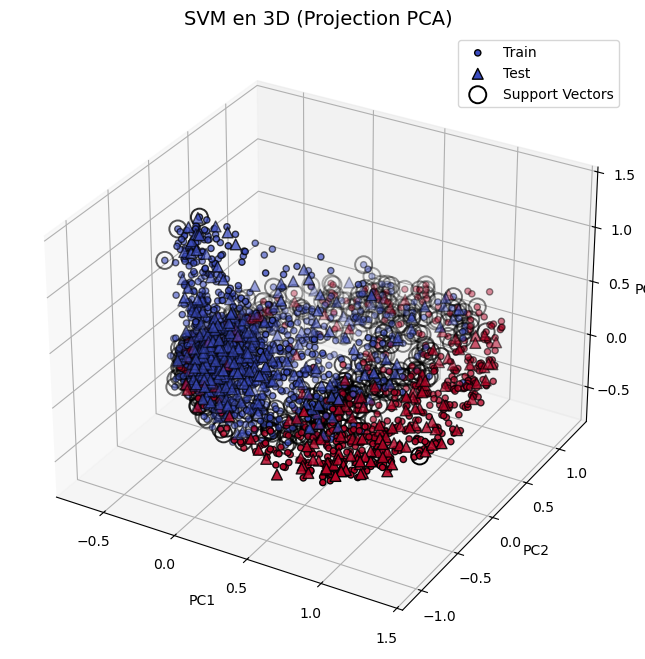

In [61]:
# ---------- Graphique SVM en 3D (PCA 3D + modèle de visualisation) ----------
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1) PCA en 3D
pca_3d = PCA(n_components=3)
X_train_3d = pca_3d.fit_transform(x_train)
X_test_3d  = pca_3d.transform(x_test)

# 2) SVM pour visualisation 3D (toujours entraîné en 3D PCA)
viz_clf_3d = SVC(kernel='rbf', C=1.0, gamma='scale')
viz_clf_3d.fit(X_train_3d, y_train)

# 3) Création de la figure 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# 4) Affichage des points entraînement
ax.scatter(
    X_train_3d[:,0], X_train_3d[:,1], X_train_3d[:,2],
    c=y_train, cmap="coolwarm", s=20, edgecolor="k", label="Train"
)

# 5) Affichage des points test
ax.scatter(
    X_test_3d[:,0], X_test_3d[:,1], X_test_3d[:,2],
    c=y_test, cmap="coolwarm", s=60, marker="^", edgecolor="k",
    label="Test"
)

# 6) Vecteurs de support
sv3d = viz_clf_3d.support_vectors_
ax.scatter(
    sv3d[:,0], sv3d[:,1], sv3d[:,2],
    facecolors="none", edgecolors="black",
    s=150, linewidth=1.4, label="Support Vectors"
)

# Labels
ax.set_title("SVM en 3D (Projection PCA)", fontsize=14)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()

plt.show()


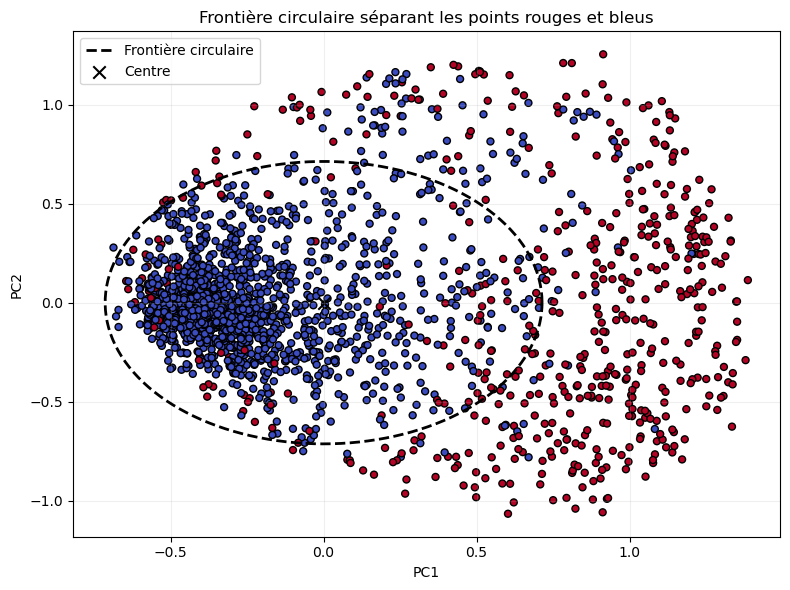

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------
# 1) PCA → réduire les données en 2D
# ------------------------------------------
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(x_train)
y = y_train   # rouge/bleu

# ------------------------------------------
# 2) Calcul du centre du cercle
#    (centre = moyenne des points)
# ------------------------------------------
center = X_train_2d.mean(axis=0)

# ------------------------------------------
# 3) Calcul du rayon
#    On prend un rayon entre les deux classes
# ------------------------------------------
dist = np.linalg.norm(X_train_2d - center, axis=1)

# rayon optimal = moyenne des distances des deux classes
radius = (dist[y==0].mean() + dist[y==1].mean()) / 2

# ------------------------------------------
# 4) Plot
# ------------------------------------------
plt.figure(figsize=(8,6))

# points (rouge / bleu)
plt.scatter(X_train_2d[:,0], X_train_2d[:,1],
            c=y, cmap="coolwarm",
            s=25, edgecolors='k')

# cercle
theta = np.linspace(0, 2*np.pi, 300)
circle_x = center[0] + radius * np.cos(theta)
circle_y = center[1] + radius * np.sin(theta)

plt.plot(circle_x, circle_y, 'k--', linewidth=2, label="Frontière circulaire")

plt.scatter(center[0], center[1], c='black', s=80, marker='x', label="Centre")
plt.title("Frontière circulaire séparant les points rouges et bleus")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
